
==Euclidean Distance==
Accuracy: 1.0
Confusion Matrix (Euclidean)


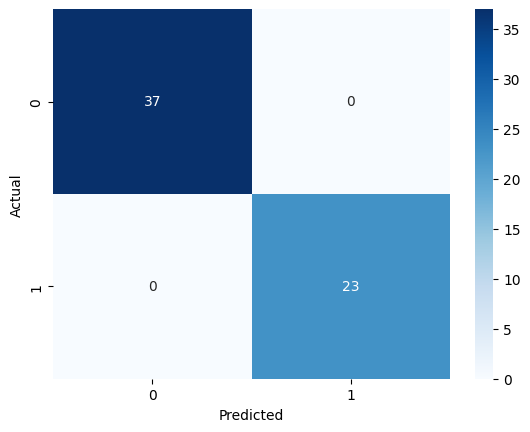

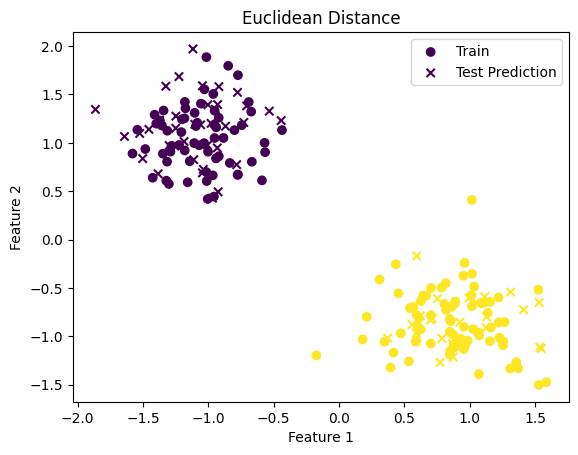


==Manhattan Distance==
Accuracy: 1.0
Confusion Matrix (Manhattan)


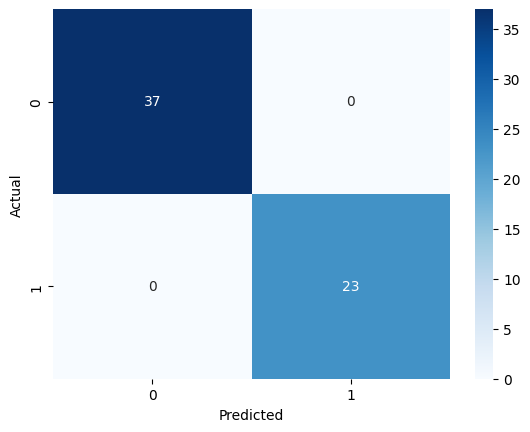

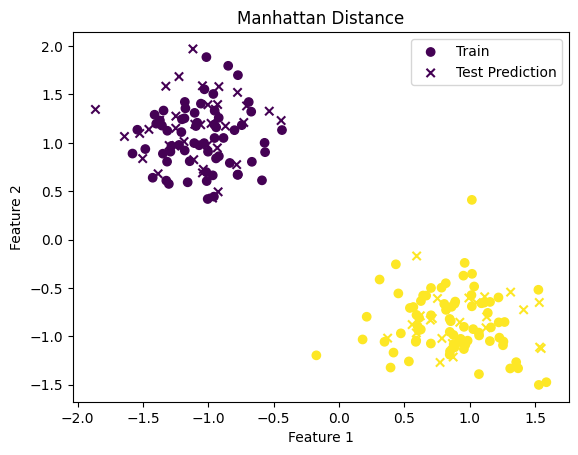


==Minkowski (p=3) Distance==
Accuracy: 1.0
Confusion Matrix (Minkowski (p=3))


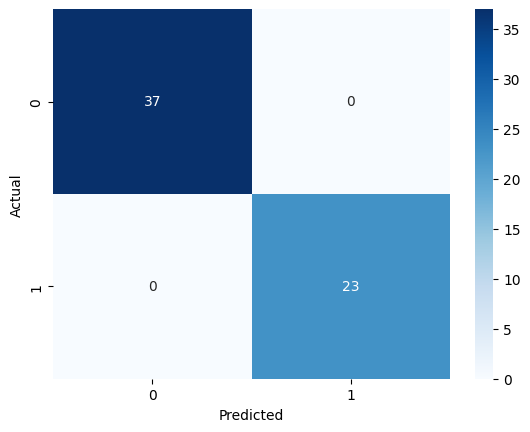

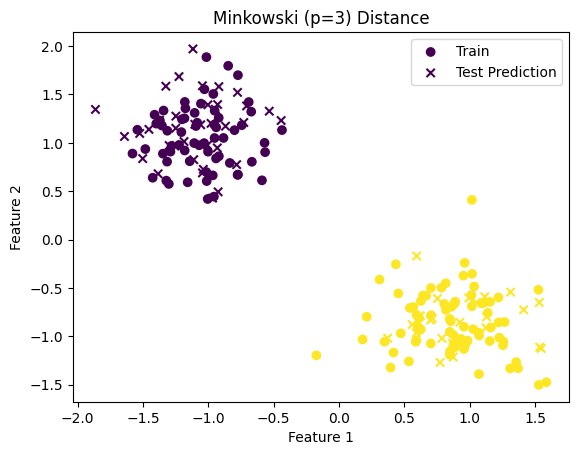

In [ ]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Fixed parameters in make_blobs
x, y = make_blobs(n_samples=200, centers=2, n_features=2, cluster_std=1.2, random_state=42)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

metrics = {
    "Euclidean": ("minkowski", 2),
    "Manhattan": ("minkowski", 1),
    "Minkowski (p=3)": ("minkowski", 3)
}

for name, (metric, p) in metrics.items():
    print(f"\n=={name} Distance==")

    # 2. Fixed class name and parameter name
    knn = KNeighborsClassifier(n_neighbors=3, metric=metric, p=p)
    knn.fit(x_train, y_train)

    # 3. Fixed syntax
    y_pred = knn.predict(x_test)

    acc = accuracy_score(y_test, y_pred)
    # 4. Define cm BEFORE plotting
    cm = confusion_matrix(y_test, y_pred)

    print("Accuracy:", acc)
    print(f"Confusion Matrix ({name})")

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    plt.scatter(x_train[:, 0], x_train[:, 1], c=y_train, cmap="viridis", label="Train")
    plt.scatter(x_test[:, 0], x_test[:, 1], c=y_pred, marker='x', cmap="viridis", label="Test Prediction")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(f"{name} Distance")
    plt.legend()
    plt.show()


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("Iris.csv")

print(df.head(3))

X = df.drop("Species", axis=1)

if "Id" in X.columns:
    X = X.drop("Id", axis=1)

y = df["Species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

metrics = {
    "Euclidean": ("minkowski", 2),
    "Manhattan": ("minkowski", 1),
    "Minkowski (p=3)": ("minkowski", 3)
}

for name, (metric, p) in metrics.items():

    print(f"\n===== {name} Distance =====")

    cv_scores = []
    k_values = range(1, 21)

    for k in k_values:
        knn = KNeighborsClassifier(
            n_neighbors=k,
            metric=metric,
            p=p
        )

        scores = cross_val_score(
            knn,
            X_train,
            y_train,
            cv=5,
            scoring="accuracy"
        )

        cv_scores.append(scores.mean())

    best_k = k_values[np.argmax(cv_scores)]

    print("Best k:", best_k)


    knn = KNeighborsClassifier(
        n_neighbors=best_k,
        metric=metric,
        p=p
    )

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", round(acc, 4))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

FileNotFoundError: [Errno 2] No such file or directory: 'Iris.csv'

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
df = pd.read_csv("Iris.csv")
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)

x = df.drop("Species", axis=1)
y = df["Species"].values
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
x_scaled = scaler.fit_transform(x)
metrics = {
    "Euclidean": ("minkowski", 2),
    "Manhattan": ("minkowski", 1),
    "Minkowski (p=3)": ("minkowski", 3)
}
for name, (metric, p) in metrics.items():
    print(f"\n== {name} Distance ==")
    cv_scores = []
    k_values = range(1, 21)
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric, p=p)
        scores = cross_val_score(knn, x_scaled, y, cv=5, scoring="accuracy")
        cv_scores.append(scores.mean())
    best_k = k_values[np.argmax(cv_scores)]
    print("Best k:", best_k)
    knn = KNeighborsClassifier(n_neighbors=best_k, metric=metric, p=p)
    knn.fit(x_train, y_train)
    y_pred = knn.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)
    plt.figure(figsize=(6, 4))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'Iris.csv'

Dataset:
   Age  Income Student Credit_Rating Buys_Computer
0   25   50000      No          Fair            No
1   30   60000     Yes     Excellent           Yes
2   28   52000     Yes          Fair           Yes
3   40   80000      No     Excellent            No
4   35   72000     Yes          Fair           Yes
5   22   48000      No          Fair            No
6   38   75000     Yes     Excellent           Yes
7   28   55000      No     Excellent           Yes

Accuracy: 0.3333333333333333


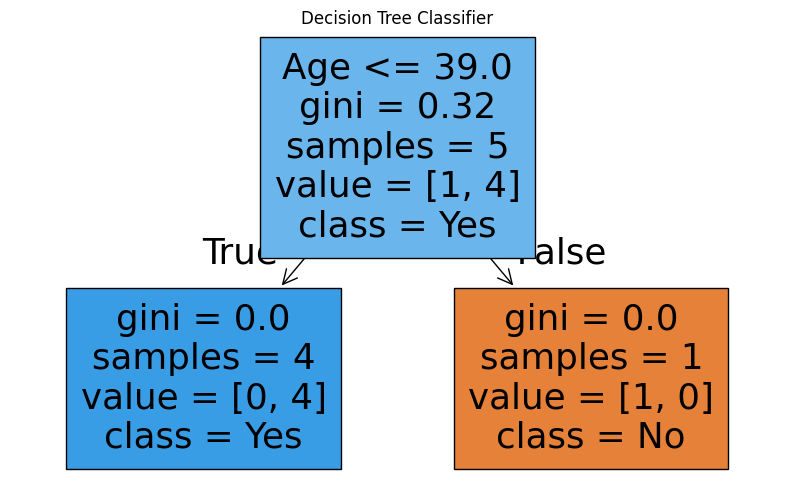

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

data = {
    'Age': [25, 30, 28, 40, 35, 22, 38, 28],
    'Income': [50000, 60000, 52000, 80000, 72000, 48000, 75000, 55000],
    'Student': ['No', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No'],
    'Credit_Rating': ['Fair', 'Excellent', 'Fair', 'Excellent',
                      'Fair', 'Fair', 'Excellent', 'Excellent'],
    'Buys_Computer': ['No', 'Yes', 'Yes', 'No',
                      'Yes', 'No', 'Yes', 'Yes']
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)

le = LabelEncoder()

df['Student'] = le.fit_transform(df['Student'])
df['Credit_Rating'] = le.fit_transform(df['Credit_Rating'])
df['Buys_Computer'] = le.fit_transform(df['Buys_Computer'])
X = df.drop('Buys_Computer', axis=1)
y = df['Buys_Computer']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

plt.figure(figsize=(10, 6))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True
)

plt.title("Decision Tree Classifier")
plt.show()

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

/tmp/ipykernel_504/1887515718.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)



Euclidean
Best K = 12
Best Accuracy = 0.7871


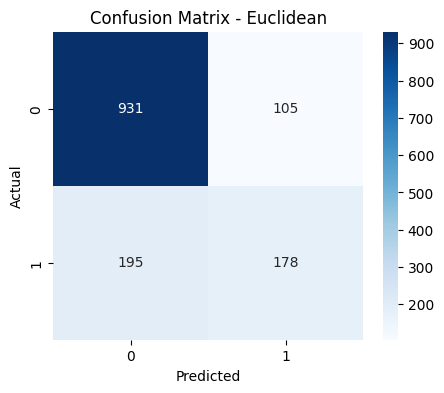

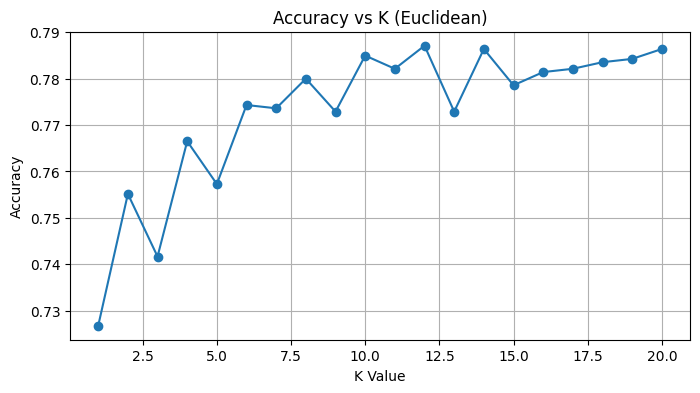


Manhattan
Best K = 16
Best Accuracy = 0.8041


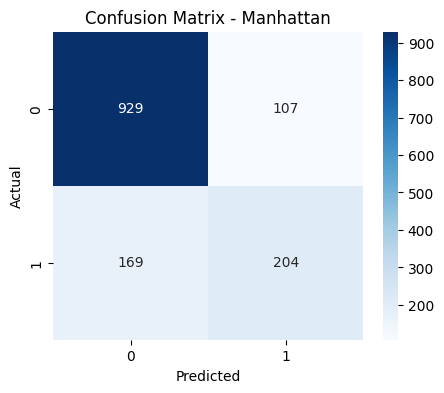

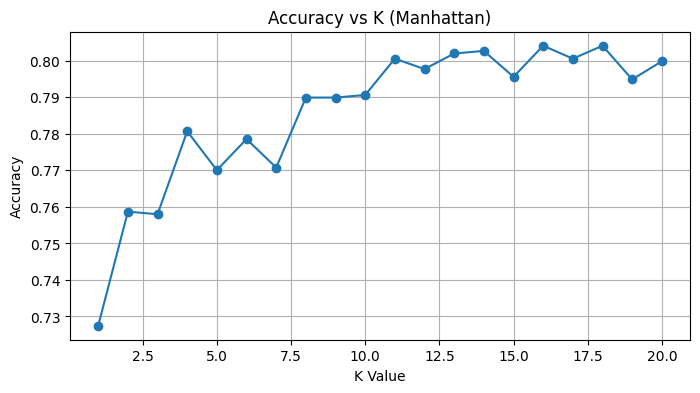


Minkowski (p=3)
Best K = 18
Best Accuracy = 0.7906


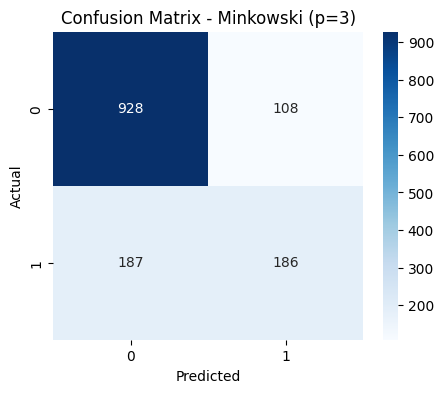

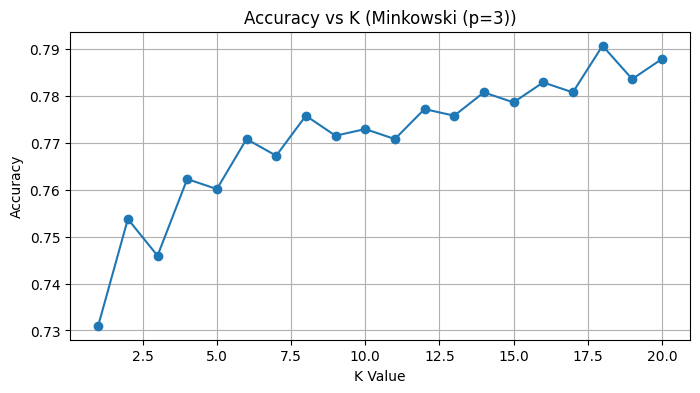

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load Dataset
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Display first rows
print(df.head())

# Data Cleaning
df.drop('customerID', axis=1, inplace=True)

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Encode categorical columns
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# Features and Target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Feature Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Distance Metrics
metrics = {
    'Euclidean': ('euclidean', None),
    'Manhattan': ('manhattan', None),
    'Minkowski (p=3)': ('minkowski', 3)
}

# Train and Evaluate
for name, (metric, p) in metrics.items():

    accuracies = []

    for k in range(1, 21):

        if metric == 'minkowski':
            model = KNeighborsClassifier(
                n_neighbors=k,
                metric=metric,
                p=p
            )
        else:
            model = KNeighborsClassifier(
                n_neighbors=k,
                metric=metric
            )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)

    # Best K
    best_k = np.argmax(accuracies) + 1
    best_acc = max(accuracies)

    print(f"\n{name}")
    print("Best K =", best_k)
    print("Best Accuracy =", round(best_acc, 4))

    # Train Best Model
    if metric == 'minkowski':
        best_model = KNeighborsClassifier(
            n_neighbors=best_k,
            metric=metric,
            p=p
        )
    else:
        best_model = KNeighborsClassifier(
            n_neighbors=best_k,
            metric=metric
        )

    best_model.fit(X_train, y_train)
    y_pred_best = best_model.predict(X_test)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_best)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Accuracy vs K Plot
    plt.figure(figsize=(8,4))
    plt.plot(range(1,21), accuracies, marker='o')
    plt.title(f'Accuracy vs K ({name})')
    plt.xlabel('K Value')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.show()